# Mapping WASP-17b MIRI/LRS from Observed MAST Light Curves

This notebook follows the WASP-18b/WASP-43b spectralmap examples, but uses **actual observed JWST MIRI/LRS time-series spectra** downloaded from MAST for the WASP-17b eclipse in Valentine et al. (2024), [doi:10.3847/1538-3881/ad5c61](https://iopscience.iop.org/article/10.3847/1538-3881/ad5c61).

Input data are generated by `build_wasp17b_miri_lrs_lightcurves.py` from the public MAST product `jw01353-o006_t001_miri_p750l-slitlessprism_x1dints.fits`. These are not synthetic phase curves. They are binned from per-integration CALJWST `x1dints` spectra and divided by a simple out-of-eclipse ramp plus linear baseline. The authors' exact ExoTiC-MIRI corrected light-curve arrays are not included in the Zenodo record, so this notebook should be treated as a MAST-pipeline reduction, not a bitwise reproduction of the paper pipeline.


## 1. Configure the notebook

In [1]:
import os
from pathlib import Path

os.environ.setdefault("THEANO_FLAGS", "base_compiledir=/private/tmp/theano")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import numpy as np
import matplotlib.pyplot as plt
import starry

starry.config.lazy = False
starry.config.quiet = True

import spectralmap
from spectralmap.plotting import COLOR_LIST

print(f"spectralmap version: {spectralmap.__version__}")

WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
/opt/miniconda3/envs/spectralmap/lib/python3.9/site-packages/starry/_core/ops/limbdark/base_op.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


spectralmap version: 0.1.0


## 2. Load observed MAST light curves

The primary arrays are cleaned/corrected for spectralmap. The `*_full` arrays keep all 1276 integrations from the MAST `x1dints` file for QA.

In [2]:
data_path = Path("data/WASP17b_MIRI_LRS_x1dints_lightcurves.npz")
npz = np.load(data_path, allow_pickle=True)

print(npz["source_note"].item())
print("kept integrations:", npz["time"].shape)
print("full integrations:", npz["time_full"].shape)
print("spectral flux:", npz["flux"].shape)
print("wavelengths:", npz["wl"])

# Cleaned arrays used by spectralmap.
time = npz["time"]
phase = npz["phase"]
phase_from_eclipse = npz["phase_from_eclipse"]
flux_white = npz["flux_white"]
flux_err_white = npz["flux_err_white"]
flux = npz["flux"]
flux_err = npz["flux_err"]
wl = npz["wl"]
bin_half_width = npz["bin_half_width"]

Observed MAST CALJWST x1dints product. Light curves are binned from per-integration extracted spectra and divided by a simple out-of-eclipse ramp+linear baseline. They are not synthetic and are not the authors' ExoTiC-MIRI corrected light curves.
kept integrations: (1155,)
full integrations: (1276,)
spectral flux: (14, 1155)
wavelengths: [ 5.25  5.75  6.25  6.75  7.25  7.75  8.25  8.75  9.25  9.75 10.25 10.75
 11.25 11.75]


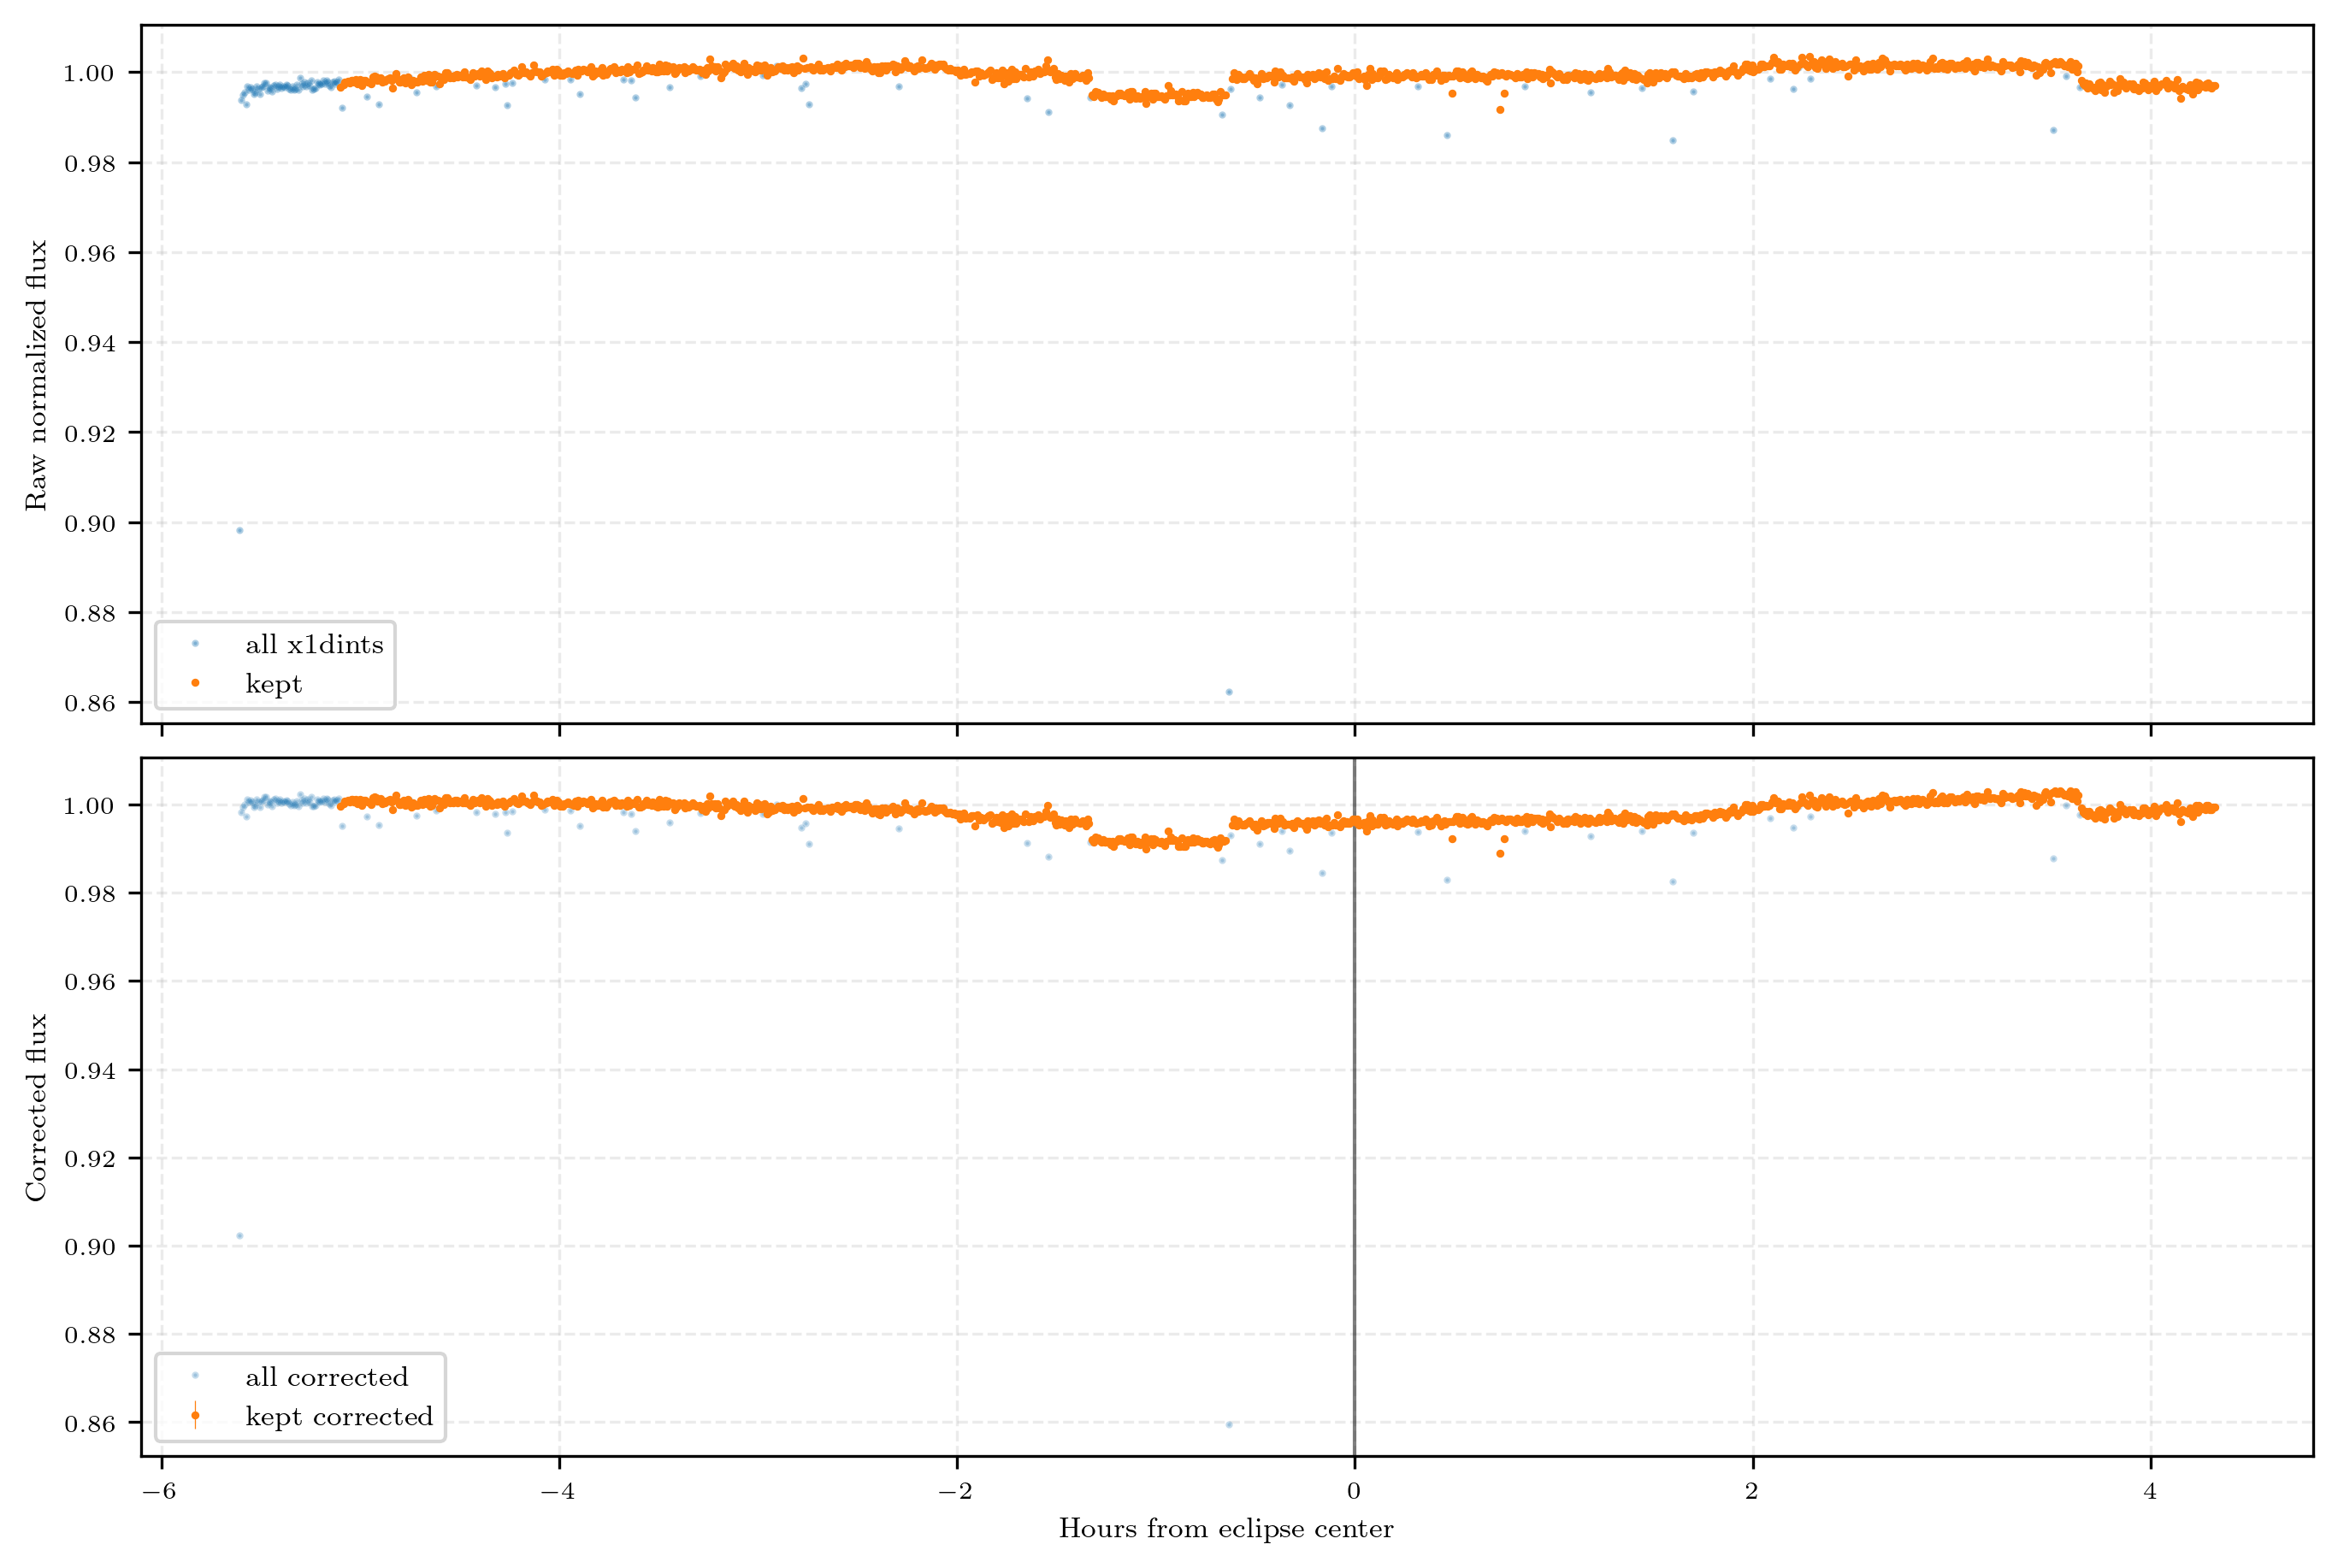

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, constrained_layout=True)

axes[0].plot((npz["time_full"] - npz["eclipse_center_mjd_tdb"]) * 24, npz["flux_white_raw_full"], '.', ms=2, alpha=0.35, label="all x1dints")
axes[0].plot((time - npz["eclipse_center_mjd_tdb"]) * 24, npz["flux_white_raw"], '.', ms=2.5, label="kept")
axes[0].set_ylabel("Raw normalized flux")
axes[0].legend(loc="best", fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot((npz["time_full"] - npz["eclipse_center_mjd_tdb"]) * 24, npz["flux_white_full"], '.', ms=2, alpha=0.25, label="all corrected")
axes[1].errorbar((time - npz["eclipse_center_mjd_tdb"]) * 24, flux_white, yerr=flux_err_white, fmt='.', ms=2.5, lw=0.3, label="kept corrected")
axes[1].axvline(0, color='k', lw=1, alpha=0.5)
axes[1].set_xlabel("Hours from eclipse center")
axes[1].set_ylabel("Corrected flux")
axes[1].legend(loc="best", fontsize=8)
axes[1].grid(alpha=0.25)
plt.show()

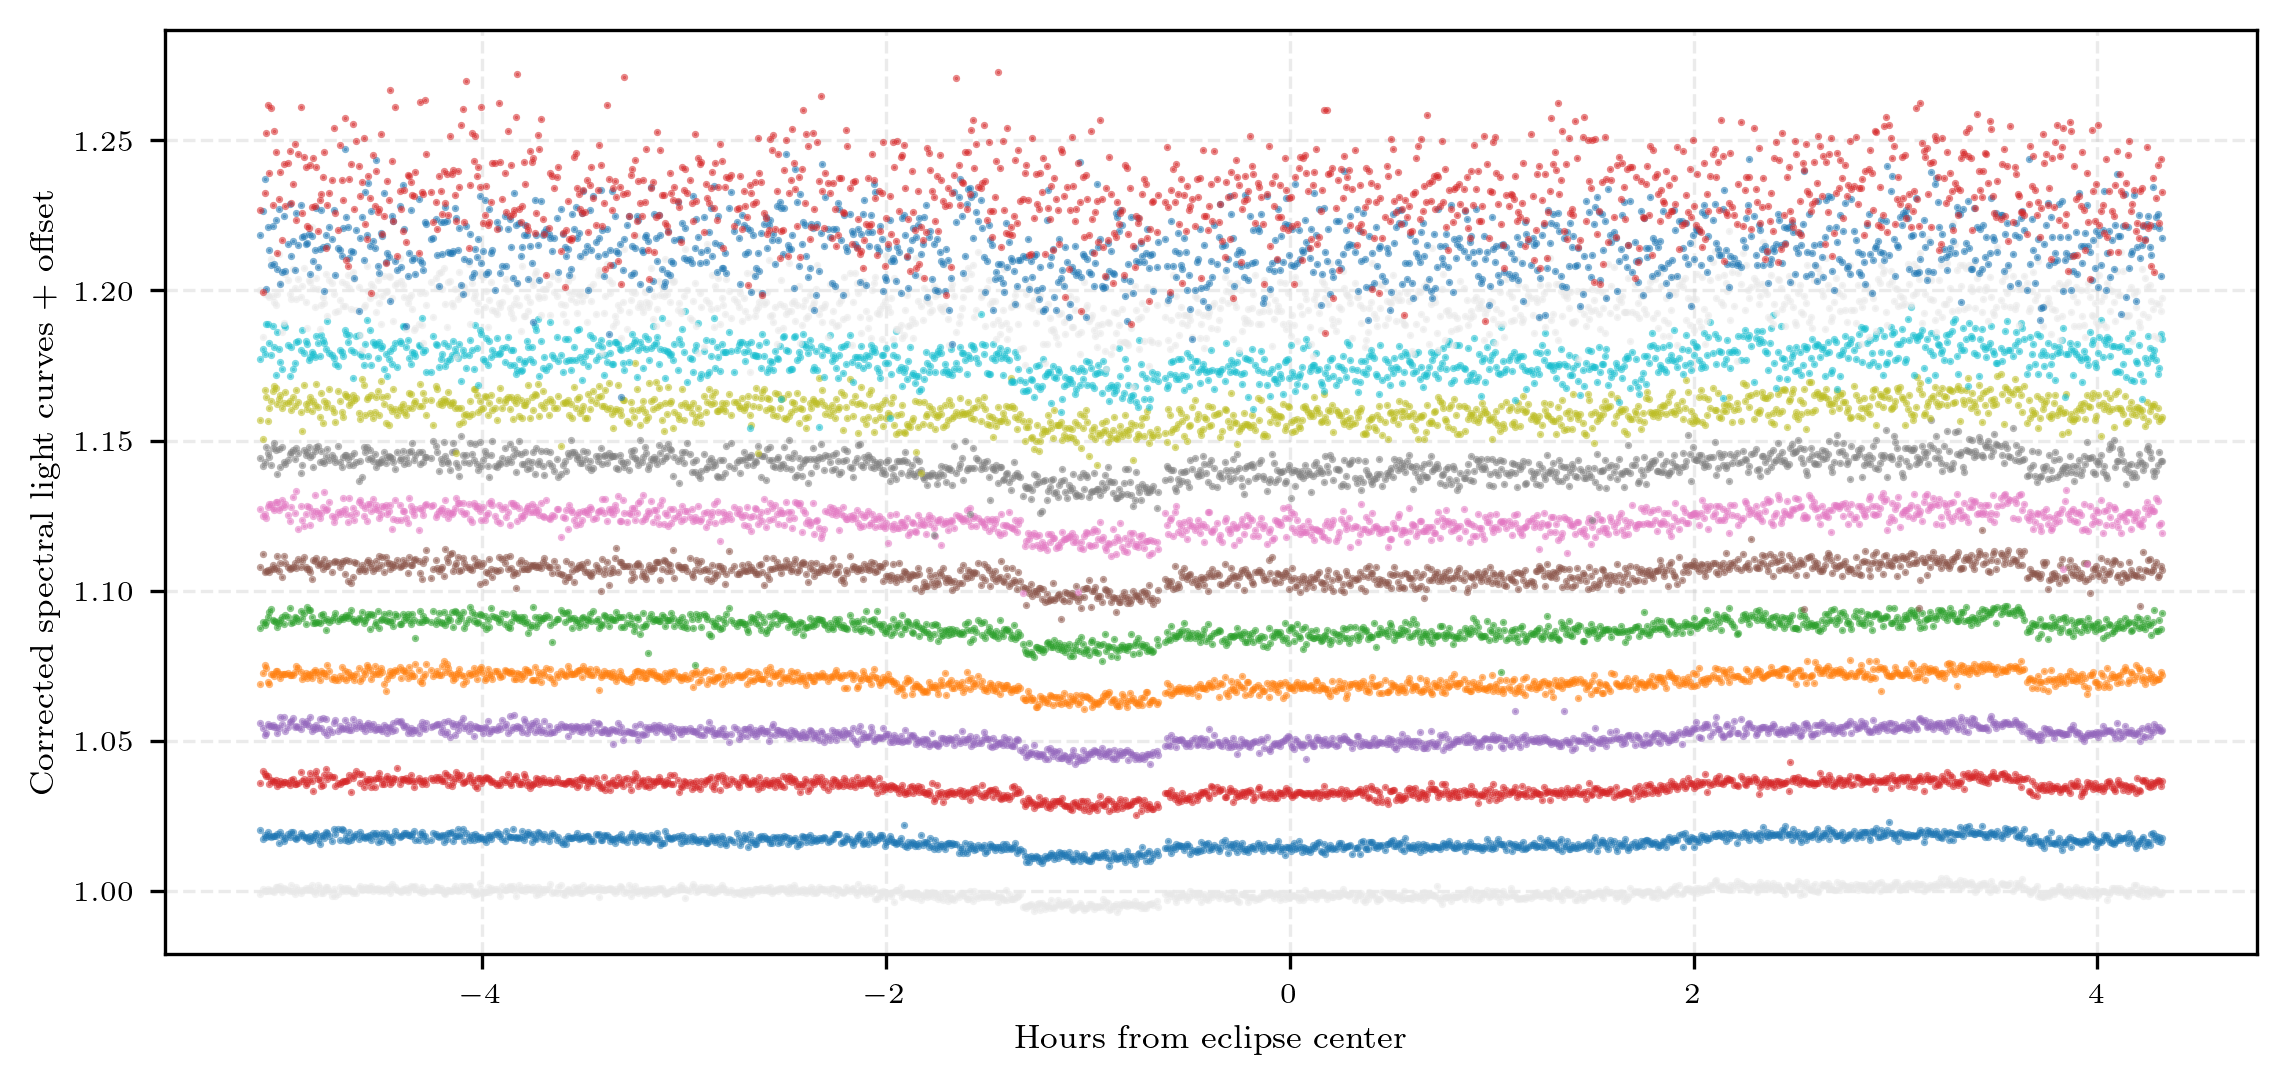

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for i in range(flux.shape[0]):
    ax.plot((time - npz["eclipse_center_mjd_tdb"]) * 24, flux[i] + 0.018 * i, '.', ms=1.5, alpha=0.55, color=COLOR_LIST[i % len(COLOR_LIST)])
ax.set_xlabel("Hours from eclipse center")
ax.set_ylabel("Corrected spectral light curves + offset")
ax.grid(alpha=0.25)
plt.show()

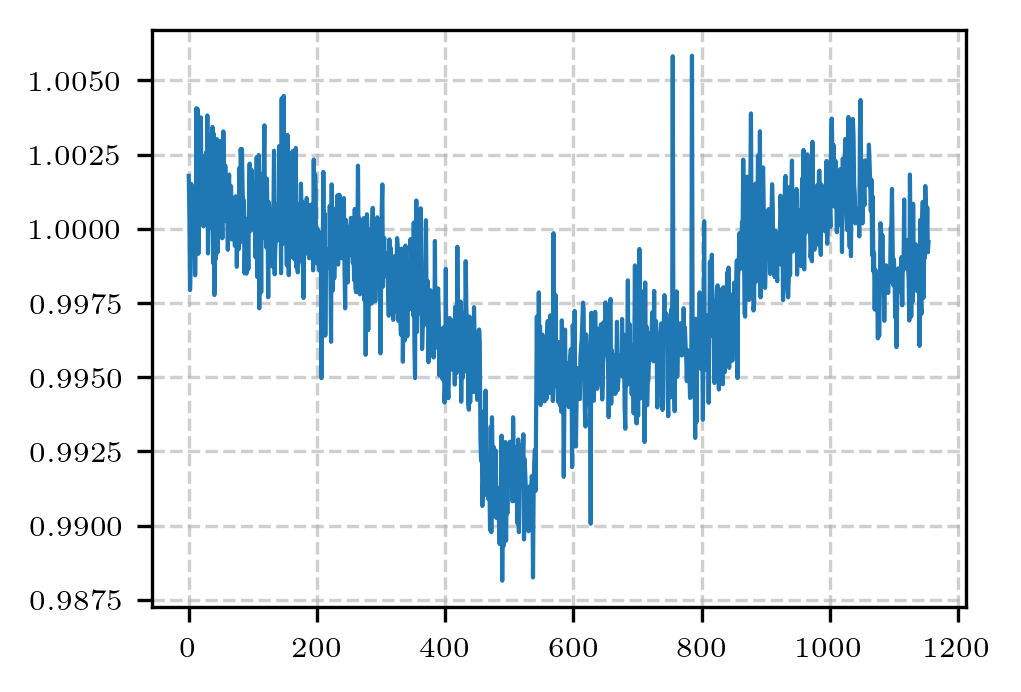

In [19]:
plt.plot(flux[3])

## 3. Define the WASP-17 system

The geometry follows the paper table values. Times are in MJD/TDB (`BJD_TDB - 2400000.5`) to match the MAST product.

In [ ]:
R_SUN = 6.957e8
R_JUP = 6.9911e7
M_SUN = 1.98847e30
M_JUP = 1.89813e27

m_star = float(npz["m_star_msun"])
r_star = float(npz["r_star_rsun"])
m_planet = float(npz["m_planet_mjup"]) * M_JUP / M_SUN
rp_rs = float(npz["rp_rs"])
r_planet = rp_rs * r_star
porb = float(npz["period_days"])
t0_ref = float(npz["t0_mjd_tdb"])
inc = float(npz["inclination_deg"])
t_star = float(npz["stellar_teff_k"])

A = dict(
    ydeg=1,
    udeg=2,
    inc=90,
    amp=1.0,
    r=r_star,
    m=m_star,
    prot=100.0,
    u=[0.05, 0.06],
)

B = dict(
    ydeg=2,
    udeg=2,
    inc=inc,
    r=r_planet,
    m=m_planet,
    porb=porb,
    prot=porb,
    t0=t0_ref,
    u=[0.0, 0.0],
    Omega=0,
    ecc=0.0,
    w=90,
)

print(f"R_p/R_* = {rp_rs:.5f}")
print(f"a/R_* = {float(npz['a_over_rstar']):.3f}")
print(f"R_p = {float(npz['r_planet_rjup']):.3f} R_Jup in the paper table")
print(f"R_p = {r_planet / (R_JUP / R_SUN):.3f} R_Jup from R_p/R_* and R_*")
print(f"Using T0 MJD/TDB: {B['t0']}")
print(f"Using period: {B['porb']}")

R_p/R_* = 0.12472
a/R_* = 7.110
R_p = 1.921 R_Jup in the paper table
R_p = 1.965 R_Jup from R_p/R_* and R_*
Using T0 MJD/TDB: 60016.226452
Using period: 3.73548546


In [6]:
pri = starry.Primary(
    starry.Map(ydeg=A["ydeg"], udeg=A["udeg"], inc=A["inc"], amp=A["amp"]),
    r=A["r"],
    m=A["m"],
    prot=A["prot"],
)
pri.map[1] = A["u"][0]
pri.map[2] = A["u"][1]

sec = starry.Secondary(
    starry.Map(ydeg=B["ydeg"], udeg=B["udeg"], inc=90),
    r=B["r"],
    m=B["m"],
    porb=B["porb"],
    prot=B["prot"],
    t0=B["t0"],
    inc=B["inc"],
    theta0=180.0,
)

## 4. Fit the white-light map

In [7]:
from spectralmap.core import LightCurveData
from spectralmap.eclipse import make_maps

white_depth_guess = 0.002579

data_white = LightCurveData(
    theta=time,
    flux=flux_white,
    flux_err=flux_err_white,
    wl=np.array([np.average(wl, weights=bin_half_width)]),
    normalize=False,
)

maps_white = make_maps(
    pri=pri,
    sec=sec,
    map_res=30,
    eclipse_depth=white_depth_guess,
    observed_lon_range=(-110, 110),
    verbose=True,
)

In [8]:
maps_white.marginalize(
    data_white,
    ydeg=np.arange(2, 4, 1),
    lamda=np.logspace(5, 9, 6),
    inc=B["inc"],
    prot=None,
    sigma_threshold=None,
)

EclipseMaps.marginalize:   0%|          | 0/12 [00:00<?, ?it/s]

(array([[1.41891638e-158],
        [9.91428105e-238],
        [0.00000000e+000],
        [0.00000000e+000],
        [0.00000000e+000],
        [0.00000000e+000],
        [1.00000000e+000],
        [6.51248633e-136],
        [0.00000000e+000],
        [0.00000000e+000],
        [0.00000000e+000],
        [0.00000000e+000]]),
 array([[ 2.33266636e-02,  2.33266636e-02,  2.33266636e-02,
          2.33266636e-02,  2.33266636e-02,  2.33266636e-02,
          2.33266636e-02,  2.33266636e-02,  2.33266636e-02,
          2.33266636e-02,  2.33266636e-02,  2.33266636e-02,
          2.33266636e-02,  2.33266636e-02,  2.33266636e-02,
          2.33266636e-02,  2.33266636e-02,  2.33266636e-02,
          2.33266636e-02,  3.79725497e-02,  3.52322181e-02,
          3.22253973e-02,  2.89719484e-02,  2.55010138e-02,
          2.18682914e-02,  1.81667491e-02,  1.45293617e-02,
          1.11243329e-02,  8.14434791e-03,  5.79160440e-03,
          4.26001521e-03,  3.71558012e-03,  4.27595509e-03,
          5.99

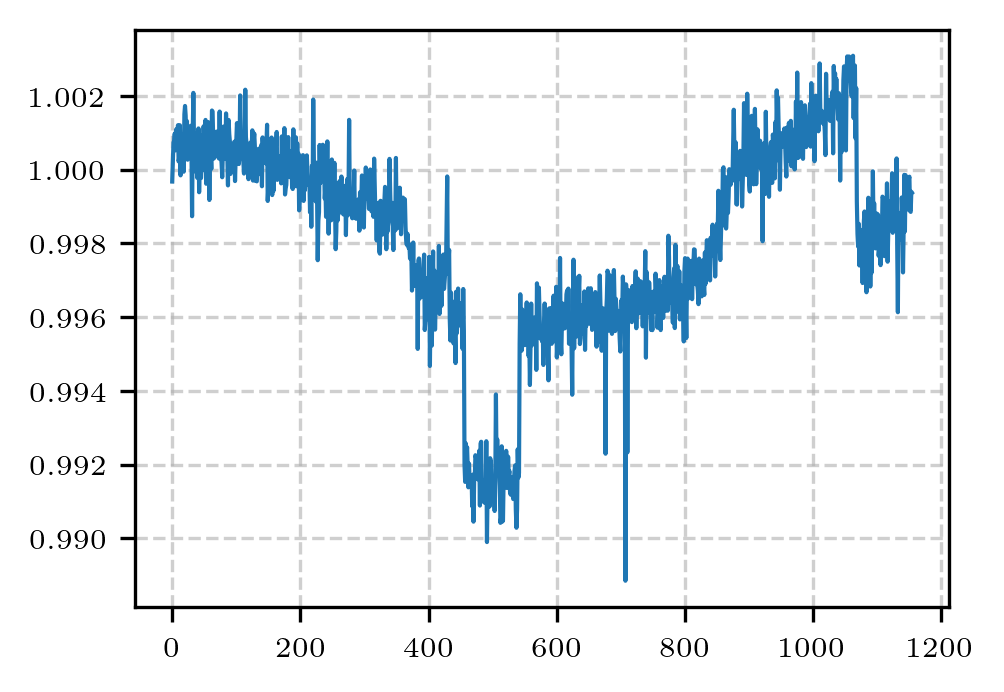

In [14]:
plt.plot(flux_white)

(<Figure size 3150x1080 with 7 Axes>,
 array([<Axes: ylabel='Latitude (deg)'>, <Axes: >, <Axes: >,
        <Axes: xlabel='Longitude (deg)', ylabel='Latitude (deg)'>,
        <Axes: xlabel='Longitude (deg)'>, <Axes: >], dtype=object))

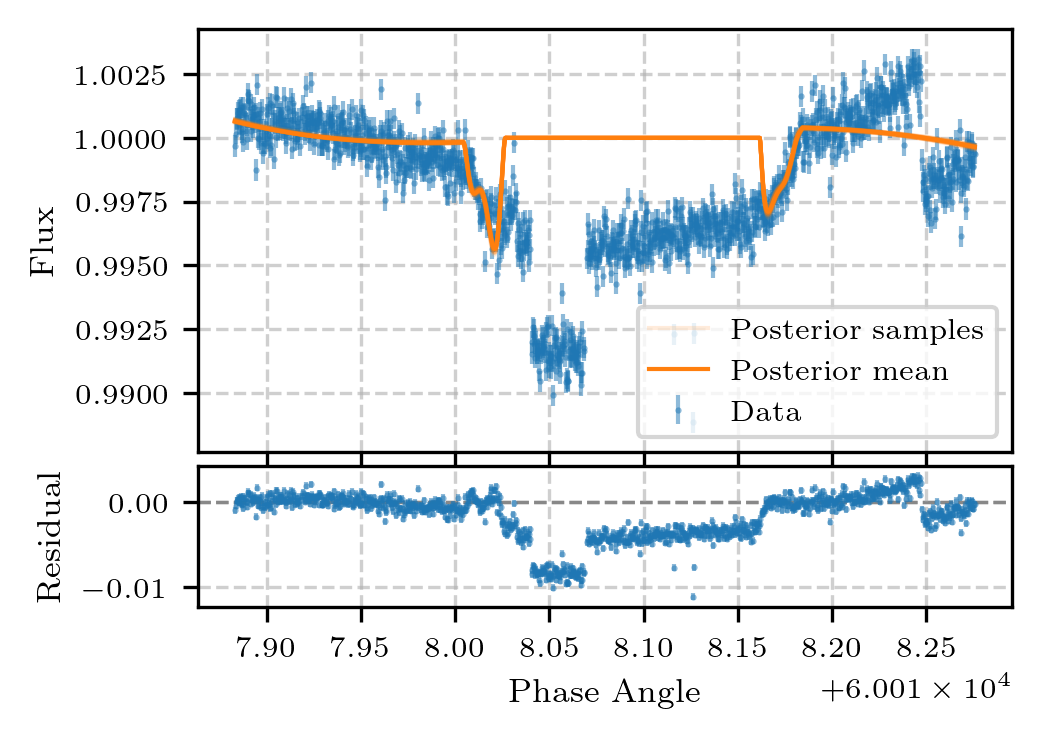

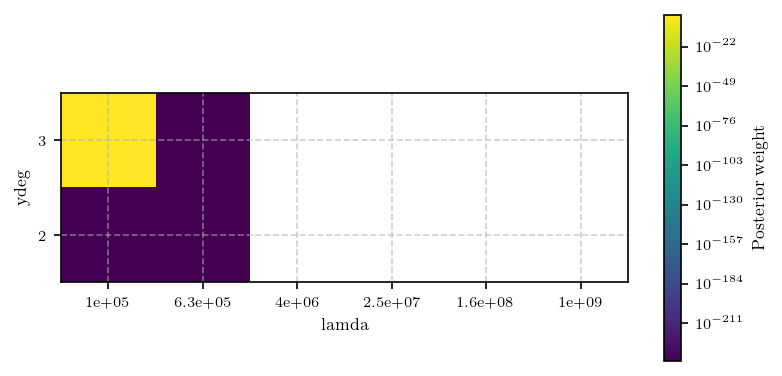

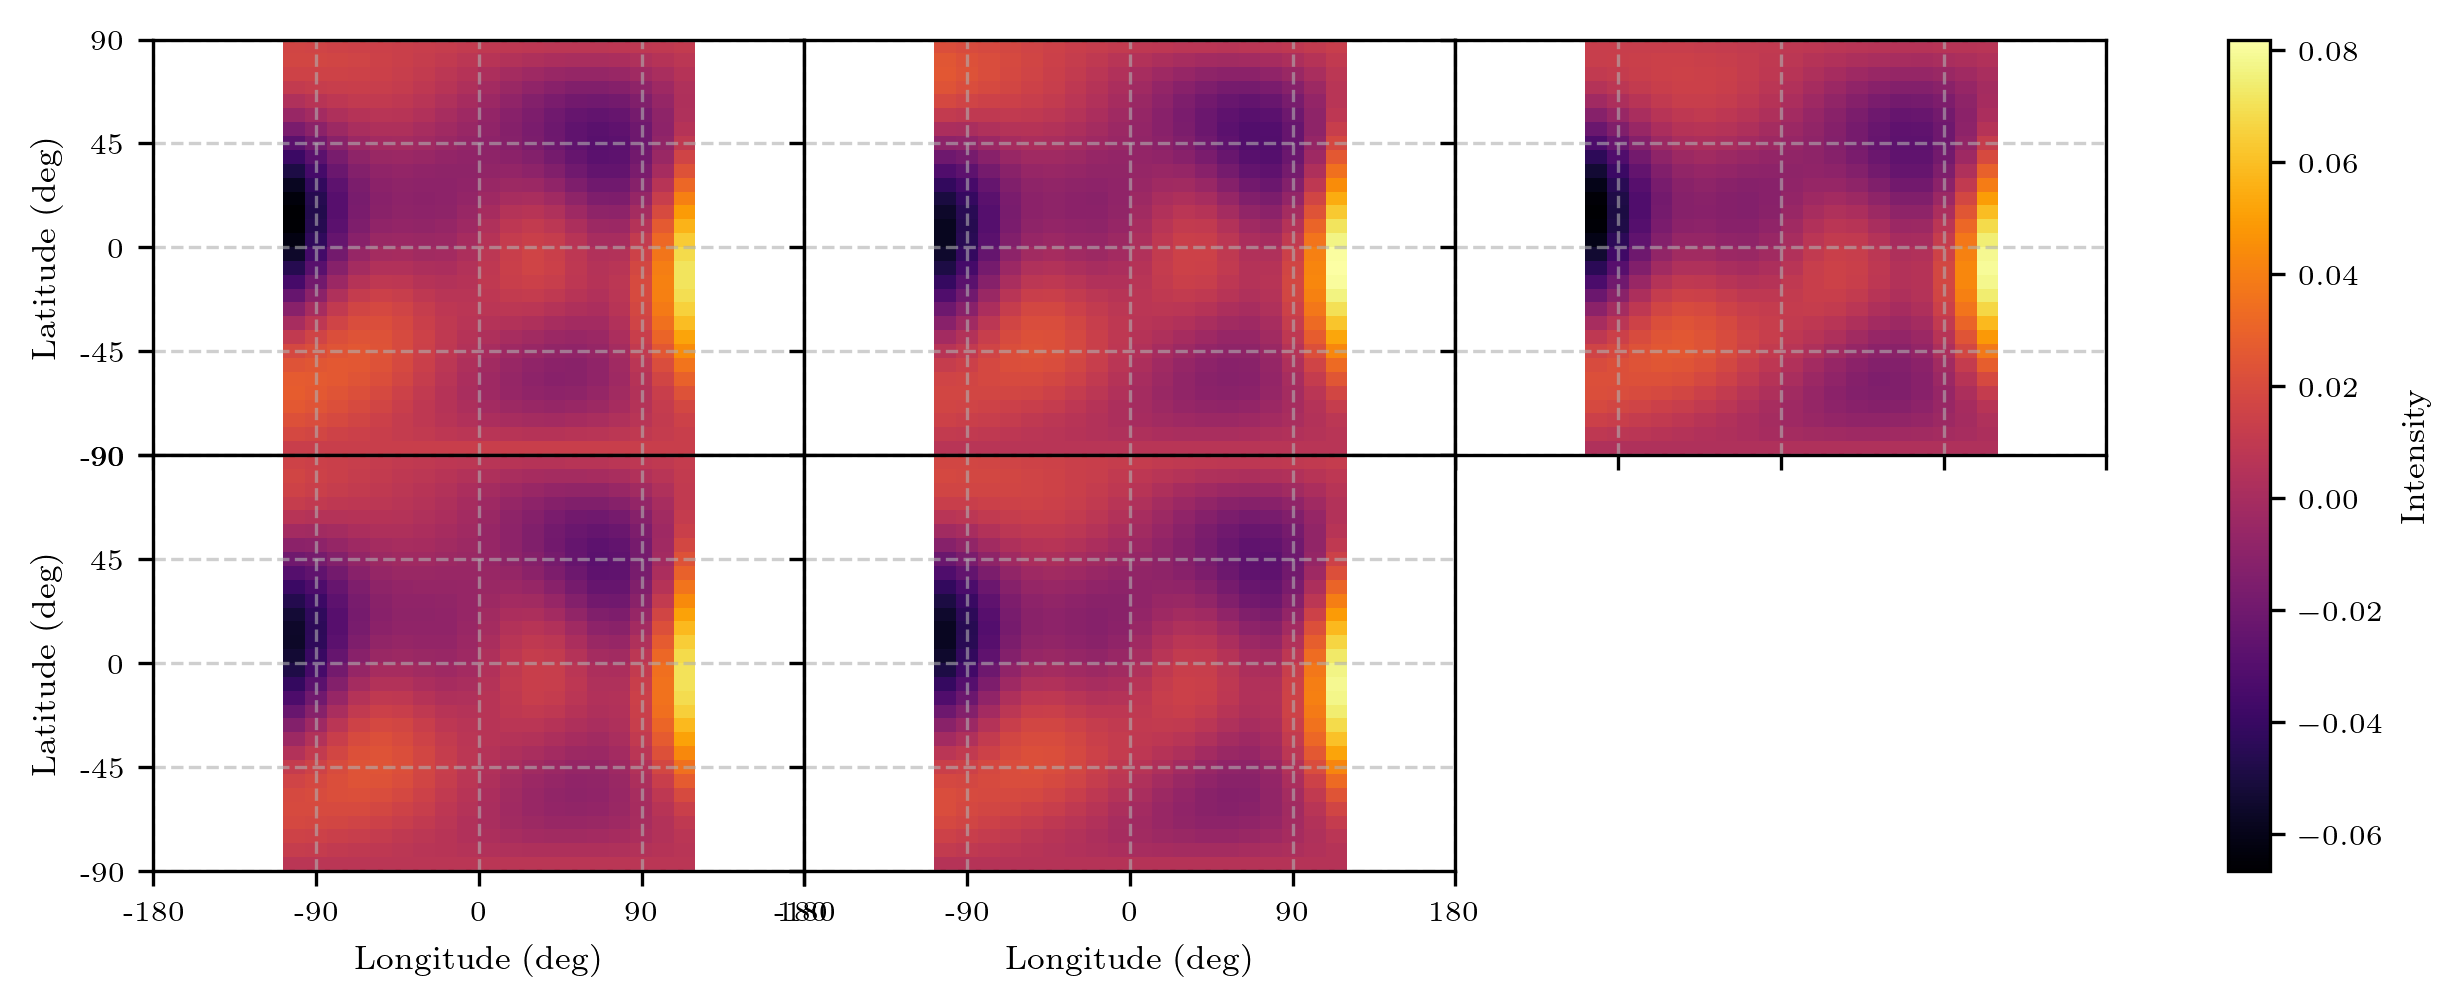

In [9]:
maps_white.plot_lightcurve(i_wl=0, n_samples=20, plot_mean=True, plot_residuals=True, random_state=1)
maps_white.plot_model_weights("lamda", "ydeg", i_wl=0, log_scale=True)
maps_white.show(i_wl=0, n_samples=5)

## 5. Fit wavelength-resolved maps

In [10]:
maps = make_maps(
    pri=pri,
    sec=sec,
    map_res=30,
    eclipse_depth=white_depth_guess,
    observed_lon_range=(-110, 110),
    verbose=True,
)

data = LightCurveData(
    theta=time,
    flux=flux,
    flux_err=flux_err,
    wl=wl,
    normalize=False,
)

In [11]:
maps.marginalize(
    data,
    ydeg=np.arange(2, 4, 1),
    lamda=np.logspace(5, 9, 6),
    inc=B["inc"],
    prot=None,
    sigma_threshold=None,
)

EclipseMaps.marginalize:   0%|          | 0/168 [00:00<?, ?it/s]

(array([[2.02404277e-006, 2.07390884e-014, 7.69784259e-010,
         3.21032582e-019, 3.86182715e-008, 9.52805710e-004,
         1.86690619e-001, 8.70367729e-001, 1.31091874e-001,
         5.45951677e-001, 2.75301255e-001, 5.09391432e-004,
         1.47661174e-006, 1.70290261e-005],
        [9.13928320e-008, 1.54707433e-021, 3.94350257e-023,
         7.87697442e-047, 9.34701533e-027, 3.00625075e-012,
         9.34917489e-011, 1.05447236e-014, 2.97014051e-012,
         2.36200626e-009, 1.42190572e-008, 2.23832321e-002,
         1.55239540e-003, 8.62905787e-003],
        [4.71781386e-018, 8.15246802e-044, 3.26956390e-059,
         6.11041919e-103, 1.21431253e-065, 2.95504102e-027,
         3.16981556e-024, 3.67000291e-028, 9.12008587e-021,
         1.90781774e-013, 1.12514657e-010, 4.17138410e-001,
         1.50258029e-001, 3.00014667e-001],
        [7.78331140e-033, 6.84866482e-067, 1.82644768e-092,
         2.69777477e-143, 2.44691088e-090, 4.10259840e-034,
         1.04771211e-029, 5.

(<Figure size 3150x1080 with 7 Axes>,
 array([<Axes: ylabel='Latitude (deg)'>, <Axes: >, <Axes: >,
        <Axes: xlabel='Longitude (deg)', ylabel='Latitude (deg)'>,
        <Axes: xlabel='Longitude (deg)'>, <Axes: >], dtype=object))

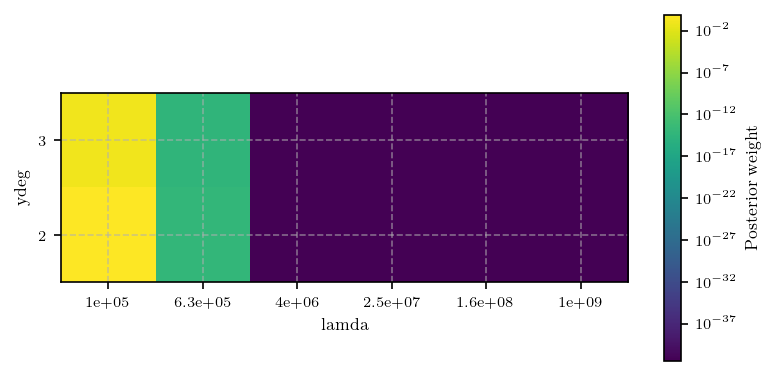

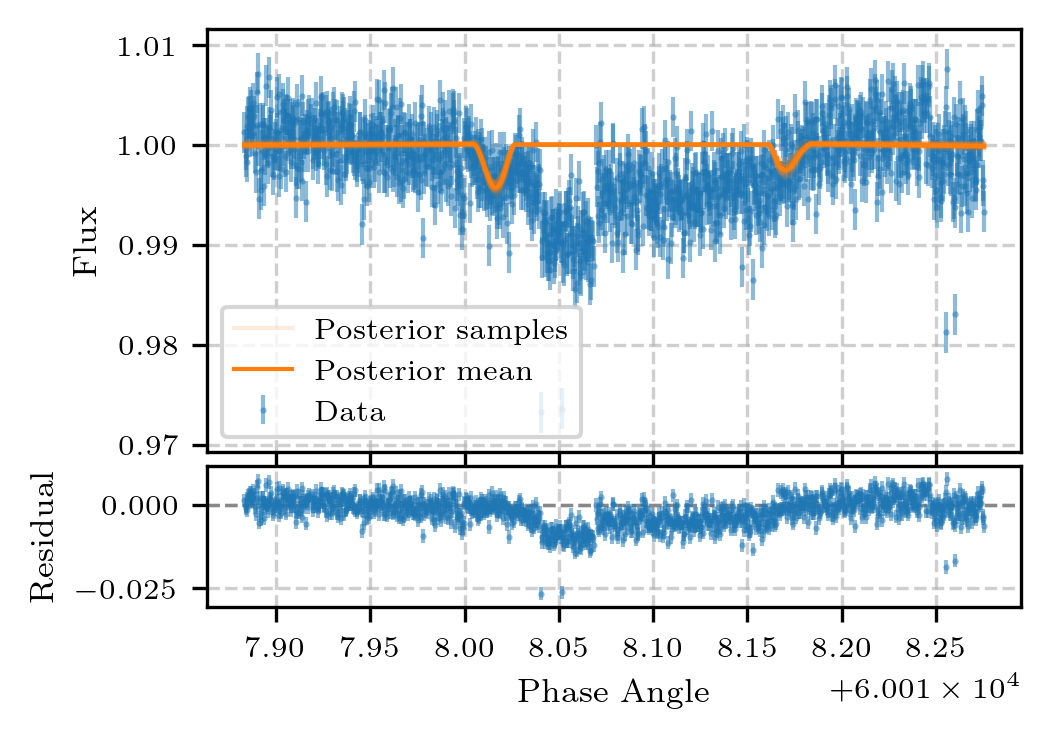

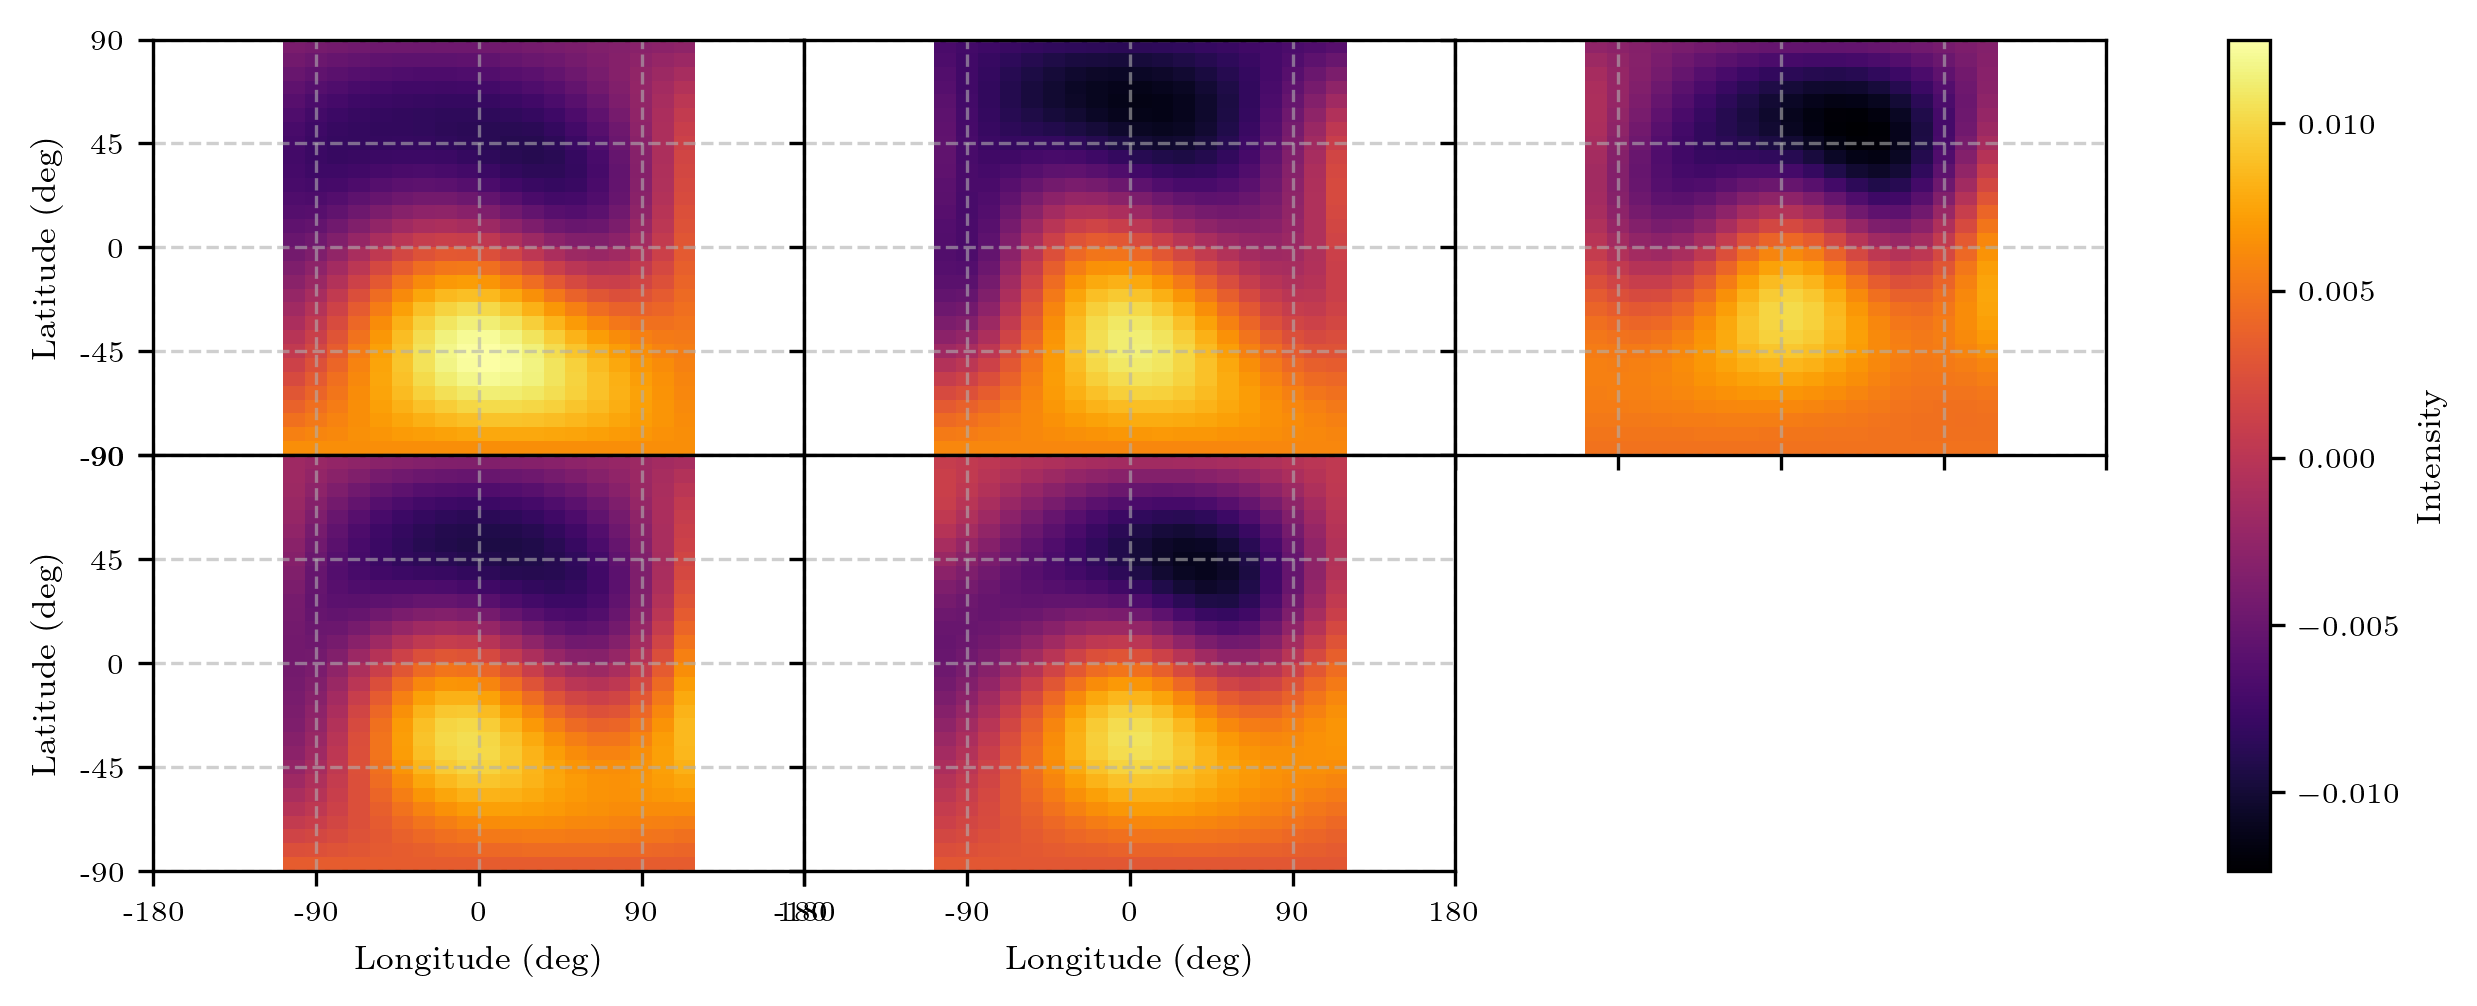

In [12]:
i_wl = len(wl) // 2
maps.plot_model_weights("lamda", "ydeg", i_wl=i_wl, log_scale=True)
maps.plot_lightcurve(i_wl=i_wl, n_samples=20, plot_mean=True, plot_residuals=True, random_state=2)
maps.show(i_wl=i_wl, n_samples=5)

## 6. Inspect spatial spectra

In [13]:
maps.find_clusters(n_corners=3, n_neighbors=80, plot=True)
regional_spectra = maps.regional_spectra
regional_spectra_std = maps.regional_spectra_std
labels = maps.labels

/Users/rworzger/Library/Mobile Documents/com~apple~CloudDocs/spectralmap/src/spectralmap/core.py:809: RuntimeWarning: invalid value encountered in log10
  log_X = np.log10(X)


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
maps.plot_pc_projection(upsample=4, extrapolate=False)
maps.plot_labels(extrapolate=False)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, y in enumerate(regional_spectra):
    yerr = regional_spectra_std[i]
    ax.errorbar(
        wl,
        1e6 * np.pi * y,
        yerr=1e6 * np.pi * yerr,
        fmt='.',
        ms=5,
        lw=0.8,
        color=COLOR_LIST[i % len(COLOR_LIST)],
        label="Background" if i == 0 else f"Region {i}",
    )
ax.set_xlabel(r"Wavelength ($\mu$m)")
ax.set_ylabel(r"$F_p/F_*$ (ppm)")
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8)
plt.show()

## Notes

The MAST product used here is real observed data, but it is not the exact ExoTiC-MIRI or Eureka! reduction from the paper. The paper's preferred ExoTiC-MIRI workflow included custom linearity handling, group trimming, background subtraction, outlier cleaning, and a systematics model with an exponential ramp, linear time term, and detector-motion decorrelation. The public Zenodo record provides spectra and diagnostic plots but not machine-readable corrected light-curve arrays. Reproducing the paper reduction exactly would require running ExoTiC-MIRI or Eureka! from lower-level MAST products with the paper's configuration and CRDS context.
